# HW5: Transition Matrix from Errored Traces

In this homework you'll upload 500 synthetic multi-tool traces to LangSmith, then pull them down and build a failure transition matrix to uncover a hidden error pattern.

**What you'll learn:**
- How to use LangSmith dashboards to view error patterns
- How to pull traces via the SDK and analyze them programmatically
- How to build and visualize a transition heatmap

## Setup

In [1]:
from dotenv import load_dotenv

load_dotenv()

True

## 1. Upload Traces to LangSmith

The file `traces.json` contains 500 pre-generated synthetic traces for a recipe agent.
Each trace uses 2-5 tool calls from 5 different tools (`web_search`, `get_recipe`, `check_dietary`, `calc_nutrition`, `convert_units`) in varying orders. Some tool calls fail with errors.

We use `upload_traces.py` to push them to LangSmith with fresh timestamps.

In [2]:
from upload_traces import upload

PROJECT_NAME = "recipe-bot-hw5"

upload(project=PROJECT_NAME)

Loaded 1830 runs from /Users/sean/Documents/ai-evals-hw-langsmith/hw5/traces.json
Shifting timestamps by: 5 days, 0:06:21.634137
Uploading 200 traces to project 'recipe-bot-hw5'...
  Uploaded 10/200 traces
  Uploaded 20/200 traces
  Uploaded 30/200 traces
  Uploaded 40/200 traces
  Uploaded 50/200 traces
  Uploaded 60/200 traces
  Uploaded 70/200 traces
  Uploaded 80/200 traces
  Uploaded 90/200 traces
  Uploaded 100/200 traces
  Uploaded 110/200 traces
  Uploaded 120/200 traces
  Uploaded 130/200 traces
  Uploaded 140/200 traces
  Uploaded 150/200 traces
  Uploaded 160/200 traces
  Uploaded 170/200 traces
  Uploaded 180/200 traces
  Uploaded 190/200 traces
  Uploaded 200/200 traces
Flushing...
Done! Uploaded 200 traces to 'recipe-bot-hw5'.


## 2. View the Dashboard (UI)

Open [smith.langchain.com](https://smith.langchain.com) and navigate to the **recipe-agent-traces** project.

### What to look for:
- **Monitor tab:** Check the error rate over time
- **Traces tab:** Filter by `error = true` to see which traces have failed tool calls
- Click into individual traces to see the full execution tree with multiple tool calls

At first glance, errors seem spread evenly across all 5 tools. Can you spot a pattern just from browsing? (Spoiler: it's hard.)

## 3. Pull Traces via SDK

Let's pull down all traces from the project and analyze the error patterns programmatically.

In [3]:
from langsmith import Client

client = Client()

# Get all runs from the project
runs = list(client.list_runs(project_name=PROJECT_NAME))
print(f"Total runs: {len(runs)}")

# Separate root runs (traces) from child runs
root_runs = [r for r in runs if r.parent_run_id is None]
child_runs = [r for r in runs if r.parent_run_id is not None]

print(f"Traces (root runs): {len(root_runs)}")
print(f"Child runs: {len(child_runs)}")

Total runs: 1830
Traces (root runs): 200
Child runs: 1630


In [4]:
# Group child runs by trace
from collections import defaultdict

trace_children = defaultdict(list)
for run in child_runs:
    trace_children[run.trace_id].append(run)

# Sort children by start_time within each trace
for trace_id in trace_children:
    trace_children[trace_id].sort(key=lambda r: r.start_time)

## 4. Analyze Error Patterns

For each trace, extract the sequence of steps and identify where errors occur.

In [5]:
# Build tool-only sequences for each trace (skip LLM routing calls)
trace_sequences = []

for root in root_runs:
    children = trace_children.get(root.trace_id, [])

    # Only keep tool runs
    tool_steps = []
    for child in children:
        if child.run_type != "tool":
            continue
        status = "error" if child.error else "ok"
        tool_steps.append((child.name, status))

    trace_sequences.append({
        "trace_id": str(root.trace_id),
        "steps": tool_steps,
        "has_error": any(s[1] == "error" for s in tool_steps),
    })

error_traces = [t for t in trace_sequences if t["has_error"]]
print(f"Traces with errors: {len(error_traces)} / {len(trace_sequences)}")

Traces with errors: 73 / 200


In [6]:
# Show a few example sequences
print("Example error traces:")
for t in error_traces[:5]:
    seq = " → ".join(f"{name}({'!' if status == 'error' else '✓'})" for name, status in t["steps"])
    print(f"  {seq}")

Example error traces:
  check_dietary(✓) → web_search(!) → convert_units(✓) → convert_units(✓) → get_recipe(✓)
  calc_nutrition(✓) → get_recipe(!) → get_recipe(✓) → web_search(✓)
  web_search(✓) → check_dietary(✓) → convert_units(!)
  check_dietary(✓) → web_search(!)
  web_search(✓) → web_search(✓) → calc_nutrition(!)


## 5. Build the Transition Matrix

For each trace, find the **last successful tool call** before an error occurs. Build a matrix of `(last_ok_tool → errored_tool)` transitions to see which tool-to-tool transitions are most failure-prone.

In [7]:
import pandas as pd

transitions = []

for trace in trace_sequences:
    steps = trace["steps"]
    for i, (name, status) in enumerate(steps):
        if status == "error":
            # Find the last successful tool call before this error
            prev_ok = "start"
            for j in range(i - 1, -1, -1):
                if steps[j][1] == "ok":
                    prev_ok = steps[j][0]
                    break
            transitions.append({"from_tool": prev_ok, "to_tool": name})

trans_df = pd.DataFrame(transitions)
print(f"Total error transitions: {len(trans_df)}")
trans_df.head(10)

Total error transitions: 87


,from_tool,to_tool
0,check_dietary,web_search
1,calc_nutrition,get_recipe
2,check_dietary,convert_units
3,check_dietary,web_search
4,web_search,calc_nutrition
5,convert_units,get_recipe
6,calc_nutrition,web_search
7,check_dietary,calc_nutrition
8,check_dietary,check_dietary
9,check_dietary,convert_units


In [8]:
# Build the transition matrix
matrix = trans_df.groupby(["from_tool", "to_tool"]).size().unstack(fill_value=0)
print("Transition matrix (last OK tool → errored tool):")
matrix

Transition matrix (last OK tool → errored tool):


to_tool,calc_nutrition,check_dietary,convert_units,get_recipe,web_search
from_tool,,,,,
calc_nutrition,0,0,3,1,5
check_dietary,13,5,10,10,12
convert_units,2,0,0,3,4
get_recipe,3,5,2,1,2
web_search,3,1,0,1,1


## 6. Visualize as Heatmap

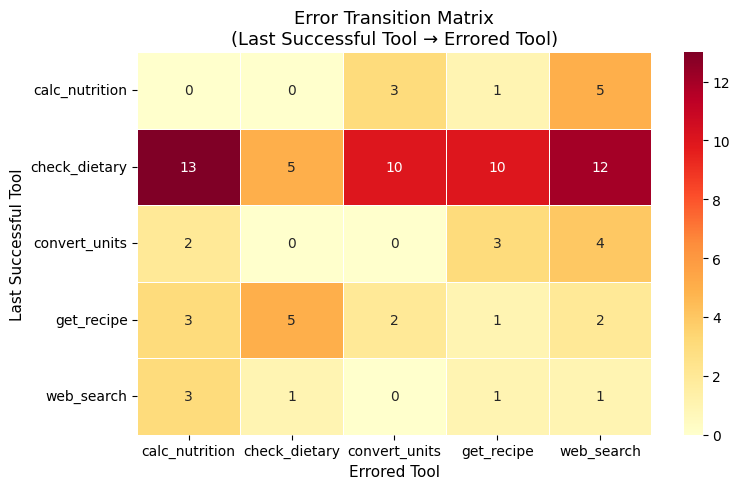

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 5))

sns.heatmap(
    matrix,
    annot=True,
    fmt="d",
    cmap="YlOrRd",
    linewidths=0.5,
    ax=ax,
)

ax.set_title("Error Transition Matrix\n(Last Successful Tool → Errored Tool)", fontsize=13)
ax.set_xlabel("Errored Tool", fontsize=11)
ax.set_ylabel("Last Successful Tool", fontsize=11)

plt.tight_layout()
plt.show()

## 7. Interpretation

The heatmap reveals a pattern that's invisible from raw error counts: **tool calls that run immediately after `check_dietary` fail at a much higher rate than normal.**

If you just look at per-tool error rates, all 5 tools fail at roughly similar rates (~9-14%). But the transition matrix shows that the *preceding step* matters — `check_dietary` is a "poison pill" that destabilizes the next tool call.

**Why this matters:**
- Per-tool error rates are misleading — they suggest all tools are equally unreliable
- Transition analysis reveals the *causal* structure: it's not *which* tool fails, it's *what ran before it*
- The fix isn't to add retries to every tool — it's to investigate what `check_dietary` does to shared state

This kind of analysis helps you:
1. Find root causes instead of treating symptoms
2. Prioritize fixes based on actual failure patterns
3. Avoid wasting effort on tools that only fail in specific contexts